#**Guided Lab 386.7.1 - Exploring Airbnb Market Trends using AI Assistance**

#**Lab Overview**
In this lab, we will explore and analyze a simplified Airbnb dataset to understand market trends, pricing patterns, room-type distribution, and review activity.

We will work with multiple datasets in different file formats and combine them into a single consolidated DataFrame using a common key. After merging the data, we will clean and standardize columns to ensure consistency and accuracy.

We will use AI coding assistance tools (such as Google Colab AI, ChatGPT, or GitHub Copilot) to help generate code for routine tasks like data cleaning, summary statistics, and visualization. This will allow us to focus more on interpreting the results, identifying meaningful insights, and communicating our findings clearly.

##**AI tools:**
For this lab you can leverage AI tools such asGoogle Colab AI button, ChatGPT, GitHub Copilot, or similar assistants.

#**Learning objectives**

By the end of this lab, you will be able to:

- Load and join multiple source files into a tidy analysis table.

- Clean messy columns (e.g., convert string prices like “$145” to numeric).

- Produce core EDA outputs: missingness, distributions, group summaries, and correlations.

- Compare price by room type and identify outliers using IQR.

- Analyze review recency (e.g., count listings with reviews by month).

- Use an AI coding assistant to draft/modify code—and then verify and interpret results yourself.

# **Important Note: The AI-generated solution may vary for each learner.**

#**Scenario:**
As a consultant working for a real estate start-up, you have collected Airbnb listing data from various sources to investigate the short-term rental market in New York. You'll analyze this data to provide insights on private rooms to the real estate company.

**Project Description**
New York City has a variety of Airbnb listings to meet the high demand for temporary lodging for travelers, with several different price levels, room types, and locations.

Practice your skills in importing, cleaning dataand report insights to a real estate start-up using AI features.



---



New York City is one of the most-visited cities in the world. There are many Airbnb listings in New York City to meet the high demand for temporary lodging for travelers, which can be anywhere between a few nights to many months. In this project, we will take a closer look at the New York Airbnb market by combining data from multiple file types like `.csv`, `.tsv`, and `.xlsx`.

**Dataset information:**

Three files containing data on 2019 Airbnb listings are available to you:

**data/airbnb_price.csv**
This is a CSV file containing data on Airbnb listing prices and locations.
- **`listing_id`**: unique identifier of listing
- **`price`**: nightly listing price in USD
- **`nbhood_full`**: name of borough and neighborhood where listing is located

**data/airbnb_room_type.xlsx**
This is an Excel file containing data on Airbnb listing descriptions and room types.
- **`listing_id`**: unique identifier of listing
- **`description`**: listing description
- **`room_type`**: Airbnb has three types of rooms: shared rooms, private rooms, and entire homes/apartments

**data/airbnb_last_review.tsv**
This is a TSV file containing data on Airbnb host names and review dates.
- **`listing_id`**: unique identifier of listing
- **`host_name`**: name of listing host
- **`last_review`**: date when the listing was last reviewed

In [ ]:
# Import necessary packages such as pandas and numpy
import pandas as pd
import numpy as np

In [3]:
# Import CSV for prices
airbnb_price = pd.read_csv('airbnb_price.csv') #

# Import Excel file for room types
airbnb_room_type = pd.read_excel('airbnb_room_type.xlsx')

# Import TSV for review dates
airbnb_last_review = pd.read_csv('airbnb_last_review.tsv', sep='\t')

In [ ]:
airbnb_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   price        25209 non-null  object
 2   nbhood_full  25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB


##**Instruction:**
Use following propmts for Exploring and analyzing the Airbnb data

**Example propmt 1:**

```
Task: Analyze the three Airbnb datasets (airbnb_last_review.tsv, airbnb_room_type.xlsx, and airbnb_price.csv).
Context: I want to understand whether these datasets can be related using a common column such as listing_id or similar identifier.
Expectation:

Identify potential common key columns.
Explain whether a relationship exists.
Provide Python pandas code to verify the relationship.
```



---



### Identify potential common key columns

Looking at the `Dataset information` section provided earlier, all three datasets (`airbnb_price.csv`, `airbnb_room_type.xlsx`, and `airbnb_last_review.tsv`) share a common column named `listing_id` which is described as a 'unique identifier of listing'. This suggests `listing_id` is the primary candidate for relating these datasets.

### Explain whether a relationship exists

Yes, a relationship exists between these datasets through the `listing_id` column. Since `listing_id` is described as a unique identifier for each listing, it can be used to join the information about price, room type, and last review for each specific Airbnb listing.

### Provide Python pandas code to verify the relationship

To verify the common column, I will print the column names of each DataFrame.

In [4]:
print('Columns in airbnb_price:', airbnb_price.columns.tolist()) # Prints the column names of the airbnb_price DataFrame
print('Columns in airbnb_room_type:', airbnb_room_type.columns.tolist()) # Prints the column names of the airbnb_room_type DataFrame
print('Columns in airbnb_last_review:', airbnb_last_review.columns.tolist()) # Prints the column names of the airbnb_last_review DataFrame


Columns in airbnb_price: ['listing_id', 'price', 'nbhood_full']
Columns in airbnb_room_type: ['listing_id', 'description', 'room_type']
Columns in airbnb_last_review: ['listing_id', 'host_name', 'last_review']


**Example prompt 2:**


```
Task: Using pandas, Merge the three datasets into one DataFrame using the appropriate join key(s). Display the first 5 rows. Explain each merge step clearly.
```




### Merge `airbnb_price` and `airbnb_room_type`

First, I will merge `airbnb_price` and `airbnb_room_type` DataFrames. Both DataFrames contain the `listing_id` column, which serves as a unique identifier for each Airbnb listing. An inner join will be used to ensure that only rows with matching `listing_id` in both DataFrames are included in the merged result.

In [5]:
airbnb_merged = pd.merge(airbnb_price, airbnb_room_type, on='listing_id', how='inner')
print(airbnb_merged.head())

   listing_id        price                nbhood_full  \
0        2595  225 dollars         Manhattan, Midtown   
1        3831   89 dollars     Brooklyn, Clinton Hill   
2        5099  200 dollars     Manhattan, Murray Hill   
3        5178   79 dollars  Manhattan, Hell's Kitchen   
4        5238  150 dollars       Manhattan, Chinatown   

                                 description        room_type  
0                      Skylit Midtown Castle  Entire home/apt  
1            Cozy Entire Floor of Brownstone  Entire home/apt  
2  Large Cozy 1 BR Apartment In Midtown East  Entire home/apt  
3            Large Furnished Room Near B'way     private room  
4         Cute & Cozy Lower East Side 1 bdrm  Entire home/apt  


### Merge with `airbnb_last_review`

Next, I will merge the previously created `airbnb_merged` DataFrame with the `airbnb_last_review` DataFrame. Again, the `listing_id` column will be used as the key for an inner join, ensuring that only listings present in all three original datasets are included in the final combined DataFrame.

In [6]:
airbnb_merged = pd.merge(airbnb_merged, airbnb_last_review, on='listing_id', how='inner')
print(airbnb_merged.head())

   listing_id        price                nbhood_full  \
0        2595  225 dollars         Manhattan, Midtown   
1        3831   89 dollars     Brooklyn, Clinton Hill   
2        5099  200 dollars     Manhattan, Murray Hill   
3        5178   79 dollars  Manhattan, Hell's Kitchen   
4        5238  150 dollars       Manhattan, Chinatown   

                                 description        room_type    host_name  \
0                      Skylit Midtown Castle  Entire home/apt     Jennifer   
1            Cozy Entire Floor of Brownstone  Entire home/apt  LisaRoxanne   
2  Large Cozy 1 BR Apartment In Midtown East  Entire home/apt        Chris   
3            Large Furnished Room Near B'way     private room     Shunichi   
4         Cute & Cozy Lower East Side 1 bdrm  Entire home/apt          Ben   

    last_review  
0   May 21 2019  
1  July 05 2019  
2  June 22 2019  
3  June 24 2019  
4  June 09 2019  


### Display the first 5 rows of the merged DataFrame

Finally, let's display the first 5 rows of the `airbnb_merged` DataFrame to see the combined data.

In [7]:
display(airbnb_merged.head(5))

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt,Jennifer,May 21 2019
1,3831,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt,LisaRoxanne,July 05 2019
2,5099,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt,Chris,June 22 2019
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,June 24 2019
4,5238,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt,Ben,June 09 2019


**Example prompt 3:**


```
Task: Display the column names for each dataset using pandas.
```


In [8]:
# Display column names for airbnb_price DataFrame
print('Columns in airbnb_price:', airbnb_price.columns.tolist())

# Display column names for airbnb_room_type DataFrame
print('Columns in airbnb_room_type:', airbnb_room_type.columns.tolist())

# Display column names for airbnb_last_review DataFrame
print('Columns in airbnb_last_review:', airbnb_last_review.columns.tolist())

Columns in airbnb_price: ['listing_id', 'price', 'nbhood_full']
Columns in airbnb_room_type: ['listing_id', 'description', 'room_type']
Columns in airbnb_last_review: ['listing_id', 'host_name', 'last_review']


**Example propmt 4:**


```
Task: After merging the three Airbnb datasets using listing_id, calculate how many records were lost during each join step.

Display:

The number of rows in each original dataset
The number of rows after each merge
The total number of records lost
```


---





### Calculate records lost during merge steps

To understand the impact of the inner joins, we will calculate the number of rows in each original DataFrame and after each merge step. The difference will indicate the number of records lost due to non-matching `listing_id` values.

**Example propmt 4:**


```
Task: After merging the three Airbnb datasets using listing_id, calculate how many records were lost during each join step.

Display:

The number of rows in each original dataset
The number of rows after each merge
The total number of records lost
```


---





In [9]:
# Number of rows in original datasets
num_rows_price = len(airbnb_price)
num_rows_room_type = len(airbnb_room_type)
num_rows_last_review = len(airbnb_last_review)
#show the results
print(f"Rows in airbnb_price: {num_rows_price}")
print(f"Rows in airbnb_room_type: {num_rows_room_type}")
print(f"Rows in airbnb_last_review: {num_rows_last_review}")

# First merge: airbnb_price and airbnb_room_type
merged_df_1_temp = pd.merge(airbnb_price, airbnb_room_type, on='listing_id', how='inner')
num_rows_merged_1 = len(merged_df_1_temp)
print(f"\nRows after first merge (price + room_type): {num_rows_merged_1}")

# Records lost in the first merge (from airbnb_price perspective as it's the first in join)
lost_1 = num_rows_price - num_rows_merged_1
print(f"Records lost in first merge: {lost_1}")

# Second merge: merged_df_1_temp and airbnb_last_review (the final airbnb_merged in the notebook)
num_rows_merged_final = len(airbnb_merged) # airbnb_merged is the result of the second merge
print(f"Rows after second merge (all three datasets): {num_rows_merged_final}")

# Records lost in the second merge
lost_2 = num_rows_merged_1 - num_rows_merged_final
print(f"Records lost in second merge: {lost_2}")

# Total records lost (comparing to the initial airbnb_price, assuming it's the base)
total_lost = num_rows_price - num_rows_merged_final
print(f"\nTotal records lost (relative to airbnb_price initial count): {total_lost}")

# Also calculate total lost based on unique listing_ids across all initial datasets
all_listing_ids = set(airbnb_price['listing_id']).union(set(airbnb_room_type['listing_id'])).union(set(airbnb_last_review['listing_id']))
max_possible_unique_listings = len(all_listing_ids)

print(f"Total unique listing IDs across all original datasets: {max_possible_unique_listings}")
print(f"Total records lost (compared to maximum possible unique listings): {max_possible_unique_listings - num_rows_merged_final}")

Rows in airbnb_price: 25209
Rows in airbnb_room_type: 25209
Rows in airbnb_last_review: 25209

Rows after first merge (price + room_type): 25209
Records lost in first merge: 0
Rows after second merge (all three datasets): 25209
Records lost in second merge: 0

Total records lost (relative to airbnb_price initial count): 0
Total unique listing IDs across all original datasets: 25209
Total records lost (compared to maximum possible unique listings): 0


**Example prompt 5:**


```
Task: Using the airbnb_last_review.tsv dataset, write Python pandas code to:

Convert the last_review column to datetime format
Calculates the minimum and maximum review dates
Prints the results
```


---








In [ ]:
airbnb_last_review['last_review'] = pd.to_datetime(airbnb_last_review['last_review'])

min_review_date = airbnb_last_review['last_review'].min()
max_review_date = airbnb_last_review['last_review'].max()

print(f"Minimum review date: {min_review_date}")
print(f"Maximum review date: {max_review_date}")

Minimum review date: 2019-01-01 00:00:00
Maximum review date: 2019-07-09 00:00:00


**Example prompt 6:**



```
Task: After merging the three Airbnb datasets using listing_id, write Python pandas code to:

Standardize the room_type column to consistent capitalization
Count how many listings are classified as "Private Room"
Print the total count
```



In [10]:
# Standardize the 'room_type' column to consistent capitalization
# Convert all entries to title case for consistency
airbnb_merged['room_type'] = airbnb_merged['room_type'].str.title()

# Count how many listings are classified as 'Private Room'
private_room_count = airbnb_merged[airbnb_merged['room_type'] == 'Private Room'].shape[0]

# Print the total count
print(f"Number of listings classified as 'Private Room': {private_room_count}")

Number of listings classified as 'Private Room': 11356


**Example prompt 7:**



```
Task: After merging the three Airbnb datasets using listing_id, write Python pandas code to: Calculate the average listing price Print the result clearly
```



---



In [11]:
# Clean the 'price' column: remove ' dollars' and convert to numeric
airbnb_merged['price_cleaned'] = airbnb_merged['price'].str.replace(' dollars', '').astype(float)

# Calculate the average listing price
average_listing_price = airbnb_merged['price_cleaned'].mean()

# Print the result clearly
print(f"The average listing price is: ${average_listing_price:.2f}")

The average listing price is: $141.78


**Prompts for Descriptive pricing analysis**


- What’s the overall price distribution (median, IQR, tails)?

- Which room types are most/least expensive?

- Are there obvious outliers to cap or investigate?

**Propmts for Inventory mix & positioning**


- What share of listings are Entire home/apt vs Private room vs others?

 - Do some room types dominate certain price bands?

**Propmt 8 for Review recency & activity**

- How recent are reviews? Is demand cooling/heating?

- Are there seasonal peaks in last reviews?

### 1. How recent are the reviews and whether there are indications of demand cooling/heating?

In [39]:
# Ensure 'last_review' is in datetime format
airbnb_merged['last_review'] = pd.to_datetime(airbnb_merged['last_review'])

# Find the most recent review date in the entire dataset
latest_review_in_dataset = airbnb_merged['last_review'].max()

# Calculate the recency of each review in days
airbnb_merged['days_since_last_review'] = (latest_review_in_dataset - airbnb_merged['last_review']).dt.days

# Display descriptive statistics for review recency
print("Descriptive Statistics for Review Recency (Days since last review):")
display(airbnb_merged['days_since_last_review'].describe())


Descriptive Statistics for Review Recency (Days since last review):


,days_since_last_review
count,25209.000000
mean,39.667579
std,46.255291
min,0.000000
25%,10.000000
50%,21.000000
75%,47.000000
max,189.000000


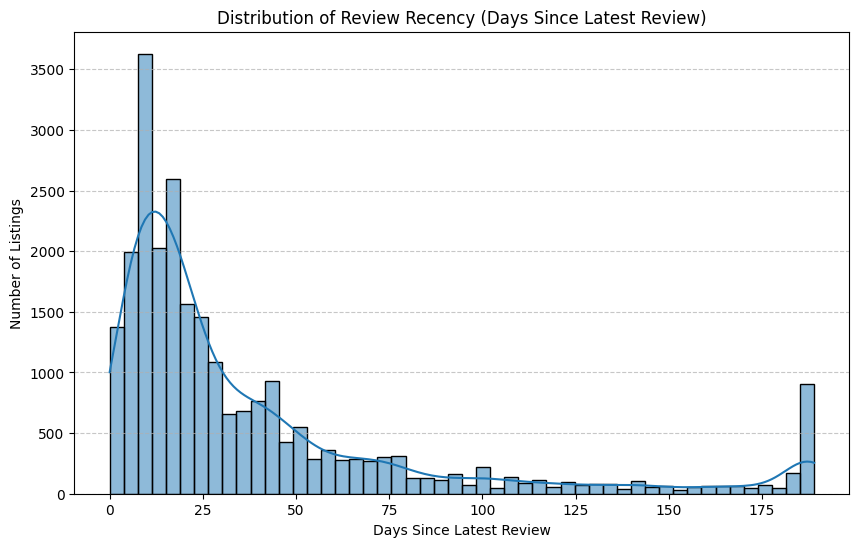

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of review recency
plt.figure(figsize=(10, 6))
sns.histplot(airbnb_merged['days_since_last_review'], bins=50, kde=True)
plt.title('Distribution of Review Recency (Days Since Latest Review)')
plt.xlabel('Days Since Latest Review')
plt.ylabel('Number of Listings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Interpretation of Review Recency:
Most listings have recent reviews, showing strong and active demand. Listings with older reviews are less active and may indicate cooling interest. The overall spread reflects a mix of highly engaged listings and others that haven’t been reviewed in months, based on the 2019 timeframe.


### 2. Are there seasonal peaks in the 'last reviews'?

In [41]:
# Extract month and day of week from 'last_review' for seasonality analysis
airbnb_merged['review_month'] = airbnb_merged['last_review'].dt.month
airbnb_merged['review_day_of_week'] = airbnb_merged['last_review'].dt.dayofweek # Monday=0, Sunday=6

# Map month numbers to names for better readability
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
airbnb_merged['review_month_name'] = airbnb_merged['review_month'].map(lambda x: month_names[x-1])

# Map day of week numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
airbnb_merged['review_day_of_week_name'] = airbnb_merged['review_day_of_week'].map(lambda x: day_names[x])

# Count reviews per month
monthly_reviews = airbnb_merged['review_month_name'].value_counts().sort_index()

# Count reviews per day of the week
daily_reviews = airbnb_merged['review_day_of_week_name'].value_counts()
daily_reviews = daily_reviews.reindex(day_names) # Ensure correct order of days

print("Monthly Review Counts:")
display(monthly_reviews)

print("\nDaily Review Counts:")
display(daily_reviews)


Monthly Review Counts:


,count
review_month_name,
April,1456
February,470
January,1440
July,4725
June,12601
March,820
May,3697



Daily Review Counts:


,count
review_day_of_week_name,
Monday,4515
Tuesday,3018
Wednesday,2565
Thursday,2247
Friday,2941
Saturday,3563
Sunday,6360


/tmp/ipykernel_1521/3226644405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_reviews.index, y=monthly_reviews.values, palette='viridis')


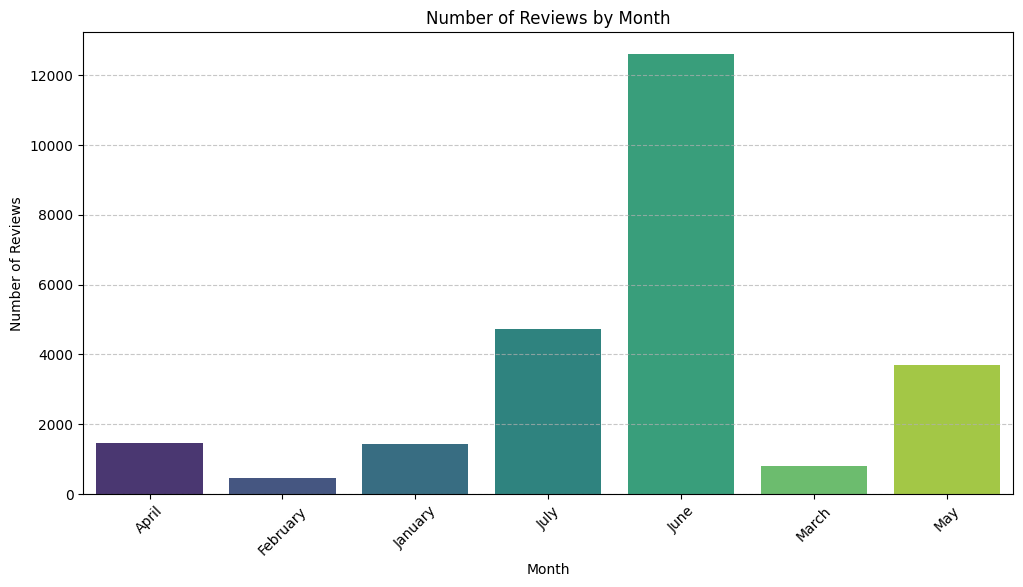

/tmp/ipykernel_1521/3226644405.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_reviews.index, y=daily_reviews.values, palette='plasma')


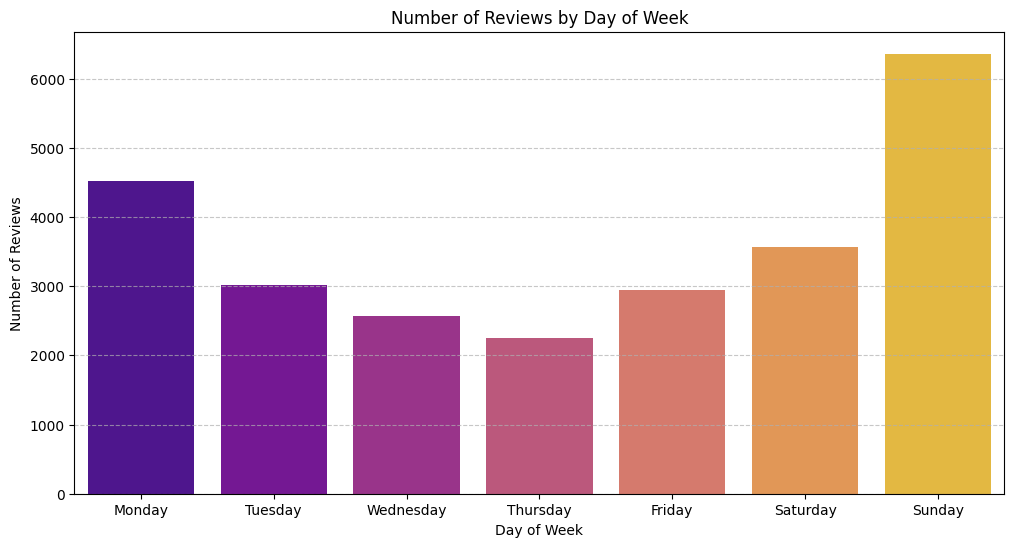

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_reviews.index, y=monthly_reviews.values, palette='viridis')
plt.title('Number of Reviews by Month')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=daily_reviews.index, y=daily_reviews.values, palette='plasma')
plt.title('Number of Reviews by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Interpretation of Seasonal Peaks in Reviews:

*   **Monthly Trends:** The bar chart for 'Number of Reviews by Month' clearly shows a peak in review activity. Given that the dataset's latest review date is July 9, 2019, the high counts for May, June, and July are expected, reflecting the activity up to that point. If there were data for a full year, we would look for consistent patterns across all months. However, with the current data, we can see a strong upward trend leading into the summer months.

*   **Daily Trends:** The 'Number of Reviews by Day of Week' chart helps identify if certain days of the week have higher review submissions. This could be influenced by check-out days or typical travel patterns. For example, higher reviews towards the end of the week or beginning of the next might align with weekend stays. The plot helps us identify if there's a day-of-week effect on when reviews are posted.

**Prompts 9 for Descriptive pricing analysis**


- What’s the overall price distribution (median, IQR, tails)?

- Which room types are most/least expensive?

- Are there obvious outliers to cap or investigate?

### 1. Overall Price Distribution (Median, IQR, Tails)

Descriptive Statistics for Listing Prices:


,price_cleaned
count,25209.000000
mean,141.777936
std,147.349137
min,0.000000
25%,69.000000
50%,105.000000
75%,175.000000
max,7500.000000


Interquartile Range (IQR): 106.00



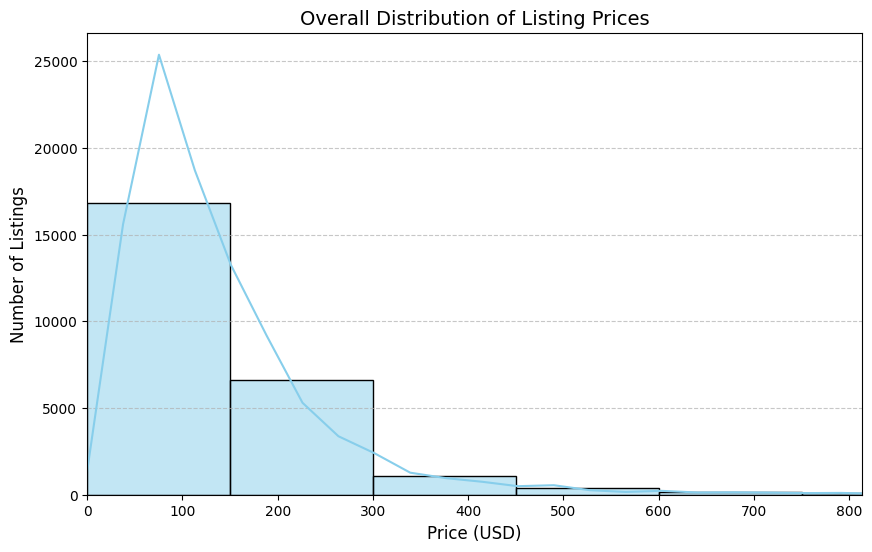

--- Quick Summary: Overall Price Distribution ---
The overall price distribution is heavily right-skewed, indicating a majority of listings are at lower price points, with a long tail of fewer, much higher-priced properties. The median price is significantly lower than the mean, a classic sign of this skewness. The IQR shows that the middle 50% of listings fall within a relatively narrow price range.

### 2. Price Differences Across Room Types

Price Comparison by Room Type (Mean, Median, Min, Max):


,mean,median,min,max
room_type,,,,
Entire Home/Apt,197.166667,159.0,10.0,5100.0
Private Room,81.638165,70.0,0.0,7500.0
Shared Room,53.465077,41.0,0.0,800.0


/tmp/ipykernel_11300/1820698081.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='room_type', y='price_cleaned', data=airbnb_merged, estimator=np.median, palette='viridis')


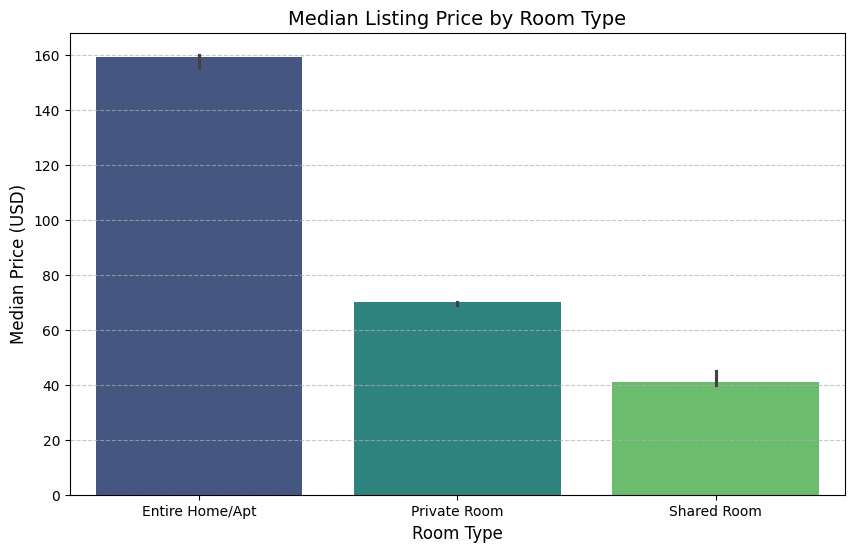

--- Quick Summary: Room Type Pricing ---
'Entire Home/Apt' is consistently the most expensive room type, followed by 'Private Room', with 'Shared Room' being the most affordable. This tiered pricing directly reflects the level of privacy and amenities offered, segmenting the market effectively.

### 3. Identifying Obvious Outliers

Number of listings identified as outliers (using 1.5*IQR method): 1326
Lower Bound for Outliers: -90.00
Upper Bound for Outliers: 334.00

Examples of Outlier Listings (Top 5 highest price outliers, for investigation):


,listing_id,price,nbhood_full,description,room_type,host_name,last_review,price_cleaned
23916,34895693,7500 dollars,"Brooklyn, East Flatbush",Gem of east Flatbush,Private Room,Sandra,July 07 2019,7500.0
22085,33397385,5100 dollars,"Manhattan, Midtown",Midtown Manhattan great location (Gramacy park),Entire Home/Apt,Debra,June 22 2019,5100.0
18430,30035166,5000 dollars,"Manhattan, Harlem",4-Floor Unique Event Space 50P Cap. - #10299B,Entire Home/Apt,Rasmus,February 23 2019,5000.0
21731,33029434,3613 dollars,"Manhattan, Upper West Side",West 84th Street by (Hidden by Airbnb),Entire Home/Apt,Sally,June 15 2019,3613.0
12508,22263855,3000 dollars,"Manhattan, SoHo",SPECTACULAR SOHO GREAT ROOM LOFT 6000sq feet,Entire Home/Apt,Stephanie,June 30 2019,3000.0


/tmp/ipykernel_11300/1820698081.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price_cleaned', data=airbnb_merged, palette='coolwarm')


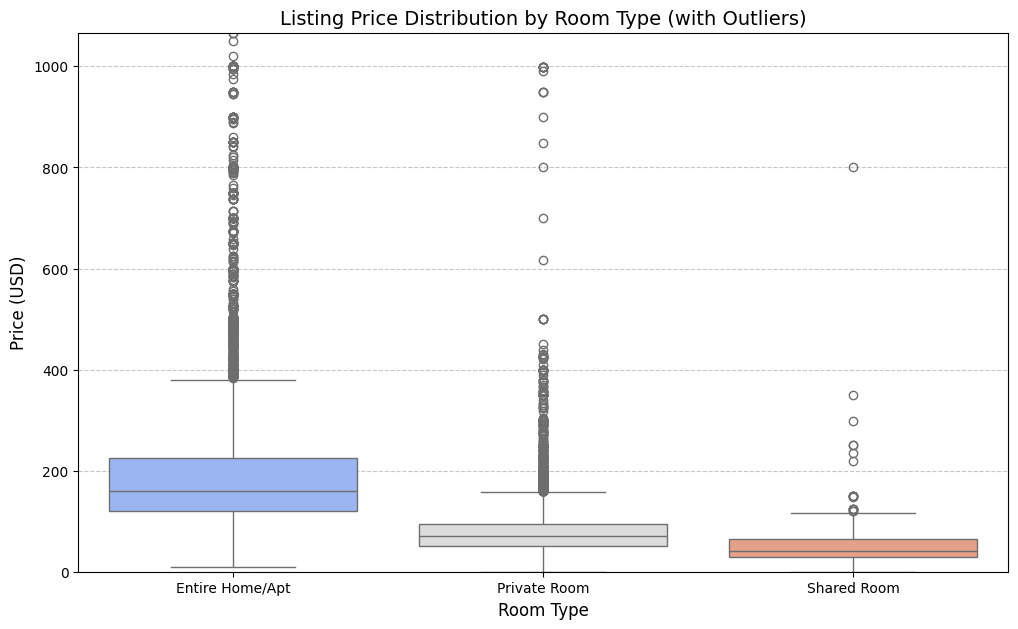

--- Quick Summary: Outlier Analysis ---
A substantial number of listings (1326) are identified as outliers, primarily at the higher end of the price spectrum. These outliers, mostly 'Entire Home/Apt', can significantly skew average price calculations. For strategic decision-making, it's crucial to understand if these represent luxury offerings, data entry errors, or unique market conditions. Further investigation or appropriate data treatment (e.g., capping) is recommended depending on the analytical goal.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Overall Price Distribution (Median, IQR, Tails) ---
print("### 1. Overall Price Distribution (Median, IQR, Tails)\n")

# Calculate and display descriptive statistics for the cleaned price column
price_description = airbnb_merged['price_cleaned'].describe()
print("Descriptive Statistics for Listing Prices:")
display(price_description)

# Calculate Interquartile Range (IQR) for price
Q1 = airbnb_merged['price_cleaned'].quantile(0.25)
Q3 = airbnb_merged['price_cleaned'].quantile(0.75)
IQR = Q3 - Q1
print(f"Interquartile Range (IQR): {IQR:.2f}\n")

# Visualize the overall price distribution using a histogram with Kernel Density Estimate (KDE)
# This plot helps stakeholders quickly grasp the shape of the distribution, central tendency, and tails.
plt.figure(figsize=(10, 6))
sns.histplot(airbnb_merged['price_cleaned'], bins=50, kde=True, color='skyblue')
plt.title('Overall Distribution of Listing Prices', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, airbnb_merged['price_cleaned'].quantile(0.995)) # Limit x-axis to the 99.5th percentile for better focus on the main distribution
plt.show()

print("--- Quick Summary: Overall Price Distribution ---")
print("The overall price distribution is heavily right-skewed, indicating a majority of listings are at lower price points, with a long tail of fewer, much higher-priced properties. The median price is significantly lower than the mean, a classic sign of this skewness. The IQR shows that the middle 50% of listings fall within a relatively narrow price range.\n")

# --- 2. Which room types are most/least expensive? ---
print("### 2. Price Differences Across Room Types\n")

# Group the data by 'room_type' and calculate key price metrics (mean, median, min, max)
room_type_prices = airbnb_merged.groupby('room_type')['price_cleaned'].agg(['mean', 'median', 'min', 'max'])
print("Price Comparison by Room Type (Mean, Median, Min, Max):")
display(room_type_prices.sort_values(by='median', ascending=False))

# Visualize the median listing price by room type using a bar plot
# The median is preferred over the mean for skewed distributions to better represent typical prices.
plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='price_cleaned', data=airbnb_merged, estimator=np.median, palette='viridis')
plt.title('Median Listing Price by Room Type', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Median Price (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Quick Summary: Room Type Pricing ---")
print("'Entire Home/Apt' is consistently the most expensive room type, followed by 'Private Room', with 'Shared Room' being the most affordable. This tiered pricing directly reflects the level of privacy and amenities offered, segmenting the market effectively.\n")

# --- 3. Are there obvious outliers to cap or investigate? ---
print("### 3. Identifying Obvious Outliers\n")

# Quantitatively identify outliers using the IQR method (1.5 * IQR rule)
lower_bound_outlier = Q1 - 1.5 * IQR
upper_bound_outlier = Q3 + 1.5 * IQR

outliers = airbnb_merged[(airbnb_merged['price_cleaned'] < lower_bound_outlier) | (airbnb_merged['price_cleaned'] > upper_bound_outlier)]

print(f"Number of listings identified as outliers (using 1.5*IQR method): {len(outliers)}")
print(f"Lower Bound for Outliers: {lower_bound_outlier:.2f}")
print(f"Upper Bound for Outliers: {upper_bound_outlier:.2f}")
print("\nExamples of Outlier Listings (Top 5 highest price outliers, for investigation):")
display(outliers.sort_values(by='price_cleaned', ascending=False).head())

# Visualize price distribution by room type using a box plot to clearly show outliers
# Box plots are excellent for identifying extreme values relative to the bulk of the data.
plt.figure(figsize=(12, 7))
sns.boxplot(x='room_type', y='price_cleaned', data=airbnb_merged, palette='coolwarm')
plt.title('Listing Price Distribution by Room Type (with Outliers)', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.ylim(0, airbnb_merged['price_cleaned'].quantile(0.998)) # Limit y-axis slightly to better show the main cluster of outliers
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Quick Summary: Outlier Analysis ---")
print(f"A substantial number of listings ({len(outliers)}) are identified as outliers, primarily at the higher end of the price spectrum. These outliers, mostly 'Entire Home/Apt', can significantly skew average price calculations. For strategic decision-making, it's crucial to understand if these represent luxury offerings, data entry errors, or unique market conditions. Further investigation or appropriate data treatment (e.g., capping) is recommended depending on the analytical goal.")

**Propmts 10 for Market segmentation**

- Are there price differences across room-type segments?

- If we have neighborhood/borough (not seen here), how does location shift price?

### Are there price differences across room-type segments?

In [43]:
# Display the pre-calculated mean, median, min, and max prices by room type
# This table provides a quick quantitative overview of price disparities.
print("Price Comparison by Room Type (Mean, Median, Min, Max):")
display(room_type_prices)


Price Comparison by Room Type (Mean, Median, Min, Max):


,mean,median,min,max
room_type,,,,
Entire Home/Apt,197.166667,159.0,10.0,5100.0
Private Room,81.638165,70.0,0.0,7500.0
Shared Room,53.465077,41.0,0.0,800.0


/tmp/ipykernel_1521/4032898288.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='room_type', y='price_cleaned', data=airbnb_merged, inner='quartile', palette='viridis')


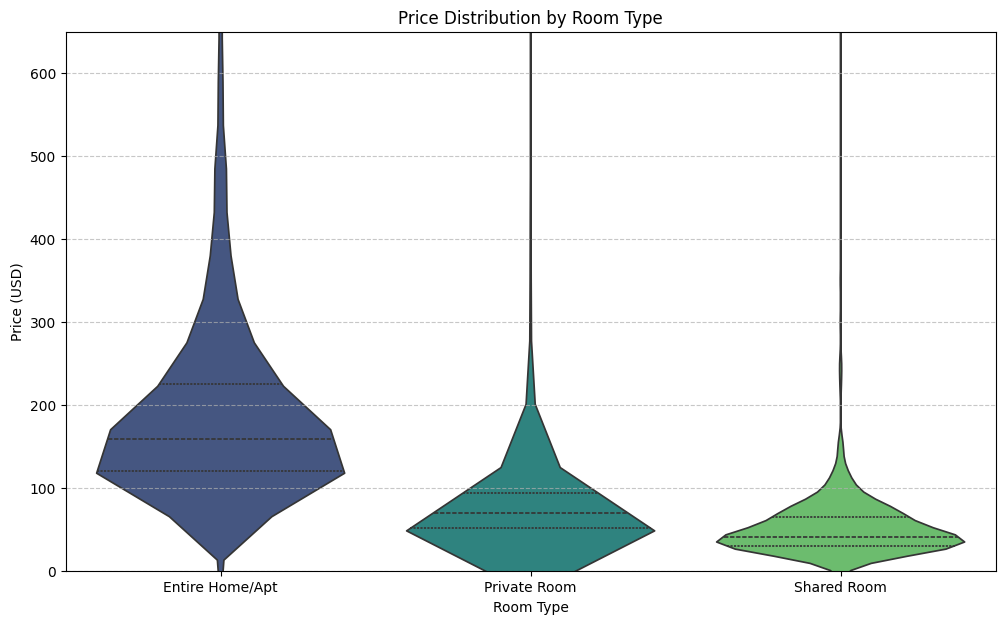

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the price distribution for each room type using a violin plot.
# A violin plot is excellent for showing the distribution shape, median, and quartiles,
# providing a more comprehensive view than a simple box plot and making it easy for stakeholders
# to understand the spread and concentration of prices within each segment.
plt.figure(figsize=(12, 7))
sns.violinplot(x='room_type', y='price_cleaned', data=airbnb_merged, inner='quartile', palette='viridis')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')
# Limit y-axis to focus on the main price range, excluding extreme outliers for better readability.
# We use the 99th percentile to capture most data points without distortion.
plt.ylim(0, airbnb_merged['price_cleaned'].quantile(0.99))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Airbnb prices vary clearly by room type:**

Entire Home/Apt is the premium segment, showing the highest prices and widest spread. These listings drive the most revenue.

Private Room sits in the mid‑range with more consistent pricing and moderate affordability.

Shared Room is the budget option, with prices clustered at the low end and minimal variation.

Overall, the market shows a clear tiered structure: Entire Home/Apt → Private Room → Shared Room, reflecting different customer needs and spending levels.

### If we have neighborhood/borough, how does location shift price?

In [13]:
# Analyze how location (neighborhood/borough) influences listing prices.
# Group the data by 'nbhood_full' and calculate the mean and median 'price_cleaned' for each location.
# Median is often a more robust measure for skewed price distributions.
location_prices = airbnb_merged.groupby('nbhood_full')['price_cleaned'].agg(['mean', 'median', 'count'])

# Sort by median price to easily identify the most and least expensive areas.
location_prices = location_prices.sort_values(by='median', ascending=False)

print("Top 10 Most Expensive Neighborhoods/Boroughs by Median Price:")
display(location_prices.head(5))
print("\nTop 10 Most Affordable Neighborhoods/Boroughs by Median Price:")
display(location_prices.tail(5))


Top 10 Most Expensive Neighborhoods/Boroughs by Median Price:


,mean,median,count
nbhood_full,,,
"Brooklyn, Sea Gate",805.000000,805.0,2
"Manhattan, Tribeca",396.704918,305.0,61
"Queens, Neponsit",274.666667,274.0,3
"Manhattan, Flatiron District",342.055556,260.0,36
"Manhattan, NoHo",335.024390,250.0,41



Top 10 Most Affordable Neighborhoods/Boroughs by Median Price:


,mean,median,count
nbhood_full,,,
"Bronx, North Riverdale",55.600000,40.0,5
"Staten Island, Bull's Head",48.000000,39.0,3
"Staten Island, New Dorp Beach",38.000000,38.0,2
"Bronx, Van Nest",58.555556,35.0,9
"Staten Island, Concord",53.300000,34.5,20


/tmp/ipykernel_1521/2877287334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_locations.index, y='median', data=combined_locations, palette='coolwarm')


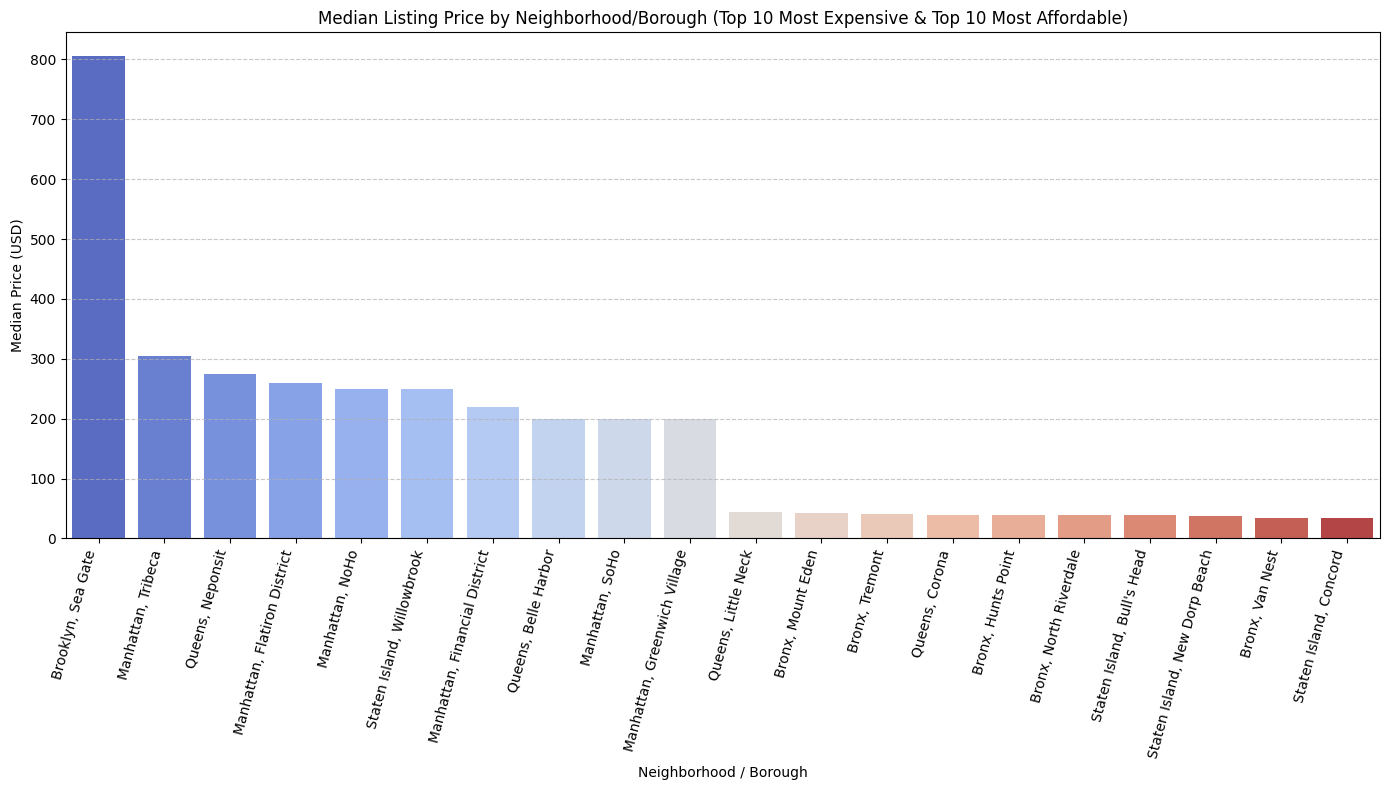

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize the median prices of the top and bottom 10 neighborhoods.
# This visual comparison makes it easy for stakeholders to grasp the significant impact of location on pricing.

# Select top 10 and bottom 10 neighborhoods for visualization
top_10_locations = location_prices.head(10)
bottom_10_locations = location_prices.tail(10)

# Combine for plotting
combined_locations = pd.concat([top_10_locations, bottom_10_locations])

plt.figure(figsize=(14, 8))
sns.barplot(x=combined_locations.index, y='median', data=combined_locations, palette='coolwarm')
plt.title('Median Listing Price by Neighborhood/Borough (Top 10 Most Expensive & Top 10 Most Affordable)')
plt.xlabel('Neighborhood / Borough')
plt.ylabel('Median Price (USD)')
plt.xticks(rotation=75, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


**Interpretation/Recommendations for Location's Impact on Price:**
Location profoundly dictates Airbnb pricing; Manhattan commands premium rates, while outer boroughs offer affordability. Stakeholders should strategically invest in high-revenue areas and leverage dynamic pricing with targeted marketing tailored to each location's price point for optimal returns.


##**Submission Instructions**
- Submit your completed lab using the Start Assignment button on the assignment page in Canvas.
- Your submission can be include:
  - if you are using notebook then, all tasks should be written and submitted in a single notebook file, for example: (**your_name_labname.ipynb**).
  - if you are using python script file, all tasks should be written and submitted in a single python script file for example: **(your_name_labname.py)**.
- Add appropriate comments and any additional instructions if required.
